# Evaluate Circuit on Real Hardware (ibm_quebec) — n=7, k=3
## Data Generation — Appendix D: Dicke states result

This script depends on the data generated by vqe_HPC_ansatz_generation.py (it creates an ansatz). 

This notebook optimizes the layout of the ansatz to get the best result on real hardware.

Steps:
1. Scan all .qpy circuits and evaluate them locally
2. Transpile ALL circuits on the best physical chain & save
3. Run ALL transpiled circuits on hardware
4. Save all results; copy the best to the main folder

## Step 1: Imports

In [1]:
import csv
import glob
import json
import os
from datetime import datetime

import numpy as np
from scipy.sparse.linalg import eigsh

from qiskit import qpy
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    EstimatorV2 as Estimator,
)

print("Imports done.")

Imports done.


## Step 2: Build Hamiltonian & scan all .qpy circuits

In [ ]:
NUM_QUBITS = 7
NUMK = 3
DATA_DIR = "/Users/guanyiheng/Downloads/bfgs_data_73"
ALL_RESULTS_DIR = "n7k3_all_results"


def dicke_state_generator_hamiltonian(number_qubits, kth_dickie_state):
    if number_qubits < 2:
        raise ValueError("Need at least two qubits.")
    paulis, coeffs = [], []
    first_term = (number_qubits / 2 - kth_dickie_state) ** 2 + (2 * number_qubits - 1) / 4
    second_term = -(number_qubits / 2 - kth_dickie_state)
    third_term = -(1.0 / (2.0 * number_qubits))
    fourth_term = 1 / 2 - (1 / (2 * number_qubits))
    for j in range(number_qubits):
        for k in range(j + 1, number_qubits):
            for pauli, coeff in [("X", third_term), ("Y", third_term), ("Z", fourth_term)]:
                term = ["I"] * number_qubits
                term[j] = term[k] = pauli
                paulis.append("".join(term))
                coeffs.append(coeff)
    for j in range(number_qubits):
        term = ["I"] * number_qubits
        term[j] = "Z"
        paulis.append("".join(term))
        coeffs.append(second_term)
    paulis.append("I" * number_qubits)
    coeffs.append(first_term)
    return SparsePauliOp.from_list(list(zip(paulis, coeffs)))


H = dicke_state_generator_hamiltonian(NUM_QUBITS, NUMK)
print(f"Hamiltonian: {len(H)} Pauli terms")

H_matrix = H.to_matrix()
exact_energy = eigsh(H_matrix, k=1, which="SA")[0][0]
print(f"Exact ground energy: {exact_energy:.10f}")

qpy_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.qpy")))
print(f"\nFound {len(qpy_files)} .qpy files in {DATA_DIR}")
print("=" * 90)
print(f"{'File':<55s} {'<H>':>12s} {'RZZ':>5s} {'Depth':>6s}")
print("-" * 90)

all_circuits = []
for qpy_path in qpy_files:
    fname = os.path.basename(qpy_path)
    with open(qpy_path, "rb") as f:
        circ = qpy.load(f)[0]
    sv = Statevector.from_instruction(circ)
    exp_val = float(np.real(sv.expectation_value(H)))
    n_rzz = circ.count_ops().get("rzz", 0)
    depth = circ.depth()
    all_circuits.append((exp_val, n_rzz, depth, fname, qpy_path, circ))
    print(f"  {fname:<53s} {exp_val:12.6e} {n_rzz:5d} {depth:6d}")

all_circuits.sort(key=lambda x: (x[1], x[0]))

print("=" * 90)
print(f"\nTop 10 circuits (sorted by fewest RZZ, then lowest <H>):")
print(f"{'File':<55s} {'<H>':>12s} {'RZZ':>5s}")
print("-" * 75)
for exp_val, n_rzz, depth, fname, _, _ in all_circuits[:10]:
    print(f"  {fname:<53s} {exp_val:12.6e} {n_rzz:5d}")

sim_csv_path = os.path.join(DATA_DIR, f"sim_summary_n{NUM_QUBITS}_k{NUMK}.csv")
with open(sim_csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["circuit_file", "expectation_value", "rzz_gates", "depth"])
    for exp_val, n_rzz, depth, fname, _, _ in all_circuits:
        writer.writerow([fname, exp_val, n_rzz, depth])
print(f"\nSaved simulation summary -> {sim_csv_path}")
print(f"({len(all_circuits)} circuits, sorted by fewest RZZ then lowest <H>)")

Hamiltonian: 71 Pauli terms
Exact ground energy: 0.0000000000

Found 144 .qpy files in /Users/guanyiheng/Downloads/bfgs_data_73
File                                                             <H>   RZZ  Depth
------------------------------------------------------------------------------------------
  In_U_n_7_numk_3_seed_0_finalexp0e4_try0.qpy           4.805931e-03   153    155
  In_U_n_7_numk_3_seed_0_finalexp0e4_try1.qpy           5.558233e-04    77     80
  In_U_n_7_numk_3_seed_1_finalexp0e4_try0.qpy           2.708286e-04    67     71
  In_U_n_7_numk_3_seed_1_finalexp0e4_try1.qpy           2.708286e-04    67     71
  In_U_n_7_numk_3_seed_2_finalexp0e4_try0.qpy           2.445997e-03    91     95
  In_U_n_7_numk_3_seed_2_finalexp0e4_try1.qpy           2.445997e-03    91     95
  In_U_n_7_numk_3_seed_3_finalexp0e4_try0.qpy           1.111992e-03    74     77
  In_U_n_7_numk_3_seed_3_finalexp0e4_try1.qpy           1.111992e-03    74     77
  In_U_n_7_numk_3_seed_4_finalexp0e4_try0.q

## Step 3: Connect to IBM Quantum

In [ ]:
MY_CRN = ""  # <-- paste your CRN
MY_TOKEN = ""  # <-- paste your IBM Quantum API token

service = QiskitRuntimeService(
    channel="ibm_cloud",
    instance=MY_CRN,
    token=MY_TOKEN,
)

backend = service.backend("ibm_quebec", use_fractional_gates=True)
print(f"Connected to: {backend.name}")
print(f"Qubits: {backend.num_qubits}")

Connected to: ibm_quebec
Qubits: 156


## Step 4: Find best physical chain & transpile ALL circuits

In [4]:
from collections import defaultdict

cmap = backend.coupling_map
adj = defaultdict(set)
for q0, q1 in cmap.get_edges():
    adj[q0].add(q1)
    adj[q1].add(q0)

print(f"Backend coupling map: {len(adj)} qubits")


def find_all_chains(adjacency, length):
    found = set()
    def dfs(node, path, visited):
        if len(path) == length:
            key = tuple(path) if path[0] < path[-1] else tuple(reversed(path))
            found.add(key)
            return
        for nbr in adjacency[node]:
            if nbr not in visited:
                visited.add(nbr)
                path.append(nbr)
                dfs(nbr, path, visited)
                path.pop()
                visited.remove(nbr)
    for start in adjacency:
        dfs(start, [start], {start})
    return [list(c) for c in found]


chains = find_all_chains(adj, NUM_QUBITS)
print(f"Found {len(chains)} candidate linear chains of {NUM_QUBITS} qubits")

tgt = backend.target
gate_2q = next((g for g in ["rzz", "ecr", "cx", "cz"] if g in tgt.operation_names), None)
print(f"Native 2q gate: {gate_2q}")


def chain_error_score(chain):
    total = 0.0
    for i in range(len(chain) - 1):
        err = None
        for pair in [(chain[i], chain[i + 1]), (chain[i + 1], chain[i])]:
            try:
                props = tgt[gate_2q][pair]
                if props is not None and props.error is not None:
                    err = props.error
                    break
            except (KeyError, TypeError):
                continue
        total += err if err is not None else 0.05
    return total


scored_chains = sorted(
    [(chain_error_score(c), c) for c in chains], key=lambda x: x[0]
)

best_score, best_chain = scored_chains[0]
print(f"\nBest chain: {best_chain}  (error score={best_score:.6f})")

Backend coupling map: 156 qubits
Found 753 candidate linear chains of 7 qubits
Native 2q gate: rzz

Best chain: [19, 35, 34, 33, 39, 53, 54]  (error score=0.005385)


In [5]:
os.makedirs(ALL_RESULTS_DIR, exist_ok=True)

pm = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend,
    initial_layout=best_chain,
)

transpiled_all = []
print(f"Transpiling {len(all_circuits)} circuits on chain {best_chain}...")
print(f"{'#':>3s}  {'File':<55s} {'Sim <H>':>12s} {'Orig RZZ':>9s} {'Trans 2q':>9s} {'Depth':>6s}")
print("-" * 100)

for idx, (exp_val, n_rzz, depth, fname, qpy_path, circ) in enumerate(all_circuits):
    tc = pm.run(circ)
    ops_c = tc.count_ops()
    n2q = ops_c.get(gate_2q, 0)
    dep = tc.depth()

    entry = {
        "idx": idx,
        "fname": fname,
        "sim_energy": exp_val,
        "original_rzz": n_rzz,
        "original_depth": depth,
        "original_circ": circ,
        "transpiled_circ": tc,
        "transpiled_2q": n2q,
        "transpiled_depth": dep,
        "transpiled_ops": dict(ops_c),
        "chain": best_chain,
        "chain_error_score": best_score,
        "H_isa": H.apply_layout(tc.layout),
    }
    transpiled_all.append(entry)
    print(f"{idx+1:3d}  {fname:<55s} {exp_val:12.6e} {n_rzz:9d} {n2q:9d} {dep:6d}")

print("=" * 100)
print(f"Transpiled all {len(transpiled_all)} circuits.")

# ---- Check & fix gate parameter bounds ----
# Heron (fractional gates): RZZ ∈ (0, π/2], RX ∈ [0, π], RZ = virtual (any angle)
from qiskit.circuit.library import RZZGate

RZZ_HI = np.pi / 2

print("\nChecking RZZ gate parameter bounds...")
total_fixed = 0
total_oob = 0

for e in transpiled_all:
    tc = e["transpiled_circ"]
    file_issues = []

    for i, inst in enumerate(tc.data):
        name = inst.operation.name
        if not inst.operation.params:
            continue
        theta = float(inst.operation.params[0])
        qbits = [q._index for q in inst.qubits]

        if name == "rzz":
            if theta < 0:
                new_theta = abs(theta)
                if new_theta > RZZ_HI + 1e-9:
                    file_issues.append(f"    {name}({theta:.6f}) -> |θ|={new_theta:.6f} STILL OUT OF (0, π/2]  qubits={qbits}")
                    total_oob += 1
                else:
                    file_issues.append(f"    {name}({theta:.6f}) -> flipped to +{new_theta:.6f}  qubits={qbits}  [FIXED]")
                    total_fixed += 1
                tc.data[i] = tc.data[i].replace(operation=RZZGate(new_theta))
            elif theta <= 0 or theta > RZZ_HI + 1e-9:
                file_issues.append(f"    {name}({theta:.6f}) OUT OF (0, π/2]  qubits={qbits}")
                total_oob += 1


    if file_issues:
        print(f"  {e['fname']}:")
        for iss in file_issues:
            print(iss)

if total_fixed > 0:
    print(f"\nFixed {total_fixed} negative RZZ angle(s) by flipping to positive.")
if total_oob > 0:
    print(f"WARNING: {total_oob} gate(s) still out of bounds after fixes!")
if total_fixed == 0 and total_oob == 0:
    print("All RZZ parameters within bounds.")

transpile_csv = os.path.join(ALL_RESULTS_DIR, "transpile_summary.csv")
with open(transpile_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["idx", "circuit_file", "sim_energy", "original_rzz", "original_depth",
                      "transpiled_2q", "transpiled_depth", "chain", "chain_error_score"])
    for e in transpiled_all:
        writer.writerow([e["idx"], e["fname"], e["sim_energy"], e["original_rzz"],
                         e["original_depth"], e["transpiled_2q"], e["transpiled_depth"],
                         e["chain"], e["chain_error_score"]])
print(f"Saved transpilation summary -> {transpile_csv}")

transpiled_qpy_dir = os.path.join(ALL_RESULTS_DIR, "transpiled_circuits")
os.makedirs(transpiled_qpy_dir, exist_ok=True)
for e in transpiled_all:
    out_path = os.path.join(transpiled_qpy_dir, f"transpiled_{e['fname']}")
    with open(out_path, "wb") as f:
        qpy.dump(e["transpiled_circ"], f)
print(f"Saved {len(transpiled_all)} transpiled circuits -> {transpiled_qpy_dir}/")

Transpiling 144 circuits on chain [19, 35, 34, 33, 39, 53, 54]...
  #  File                                                         Sim <H>  Orig RZZ  Trans 2q  Depth
----------------------------------------------------------------------------------------------------
  1  U_n_7_numk_3_seed_2_firstbelow005_try1.qpy              4.067003e-02        22        20     26
  2  U_n_7_numk_3_seed_2_firstbelow003_try1.qpy              2.865016e-02        23        22     26
  3  U_n_7_numk_3_seed_6_firstbelow005_try1.qpy              3.181774e-02        23        23     26
  4  U_n_7_numk_3_seed_6_firstbelow005_try2.qpy              4.957391e-02        23        23     26
  5  U_n_7_numk_3_seed_7_firstbelow005_try0.qpy              3.231221e-02        24        23     26
  6  U_n_7_numk_3_seed_3_firstbelow005_try0.qpy              4.725290e-02        24        23     26
  7  U_n_7_numk_3_seed_7_firstbelow003_try0.qpy              2.557804e-02        25        24     29
  8  U_n_7_numk_3_seed_6_

## Step 5: Run ALL transpiled circuits on hardware

In [6]:
SHOTS = 16000
RESILIENCE = 0

print(f"Will evaluate {len(transpiled_all)} circuits on {backend.name}")
print(f"  Shots: {SHOTS}, Resilience: {RESILIENCE}")
print(f"  Exact ground energy: {exact_energy:.10f}")
print("=" * 110)
print(f"{'#':>3s}  {'File':<55s} {'Sim <H>':>10s} {'HW <H>':>10s} {'Std':>10s} {'2q':>4s} {'JobID'}")
print("-" * 110)

estimator = Estimator(mode=backend)
estimator.options.resilience_level = RESILIENCE
estimator.options.default_shots = SHOTS

for e in transpiled_all:
    t0 = datetime.now()
    job = estimator.run([(e["transpiled_circ"], e["H_isa"])])
    job_result = job.result()
    elapsed = (datetime.now() - t0).total_seconds()

    hw_energy = float(job_result[0].data.evs)
    hw_std = float(job_result[0].data.stds) if hasattr(job_result[0].data, "stds") else None
    job_id = job.job_id() if hasattr(job, "job_id") else None

    e["hw_energy"] = hw_energy
    e["hw_std"] = hw_std
    e["hw_error"] = hw_energy - exact_energy
    e["job_id"] = job_id
    e["elapsed_s"] = elapsed
    e["shots"] = SHOTS
    e["resilience_level"] = RESILIENCE

    std_s = f"{hw_std:.6f}" if hw_std is not None else "N/A"
    print(f"{e['idx']+1:3d}  {e['fname']:<55s} {e['sim_energy']:10.2e} {hw_energy:10.6f} {std_s:>10s} {e['transpiled_2q']:4d} {job_id}")

print("=" * 110)
print(f"All {len(transpiled_all)} evaluations complete.")

Will evaluate 144 circuits on ibm_quebec
  Shots: 16000, Resilience: 0
  Exact ground energy: 0.0000000000
  #  File                                                       Sim <H>     HW <H>        Std   2q JobID
--------------------------------------------------------------------------------------------------------------
  1  U_n_7_numk_3_seed_2_firstbelow005_try1.qpy                4.07e-02   0.360080   0.018814   20 d6f5hjng4t5c7388k82g
  2  U_n_7_numk_3_seed_2_firstbelow003_try1.qpy                2.87e-02   0.344804   0.018818   22 d6f5hong4t5c7388k890
  3  U_n_7_numk_3_seed_6_firstbelow005_try1.qpy                3.18e-02   0.323473   0.018803   23 d6f5htknsg9c739datpg
  4  U_n_7_numk_3_seed_6_firstbelow005_try2.qpy                4.96e-02   0.371214   0.018801   23 d6f5i3fg4t5c7388k8kg
  5  U_n_7_numk_3_seed_7_firstbelow005_try0.qpy                3.23e-02   0.355714   0.018812   23 d6f5i9154hss73bbnkg0
  6  U_n_7_numk_3_seed_3_firstbelow005_try0.qpy                4.73e-02   0.3

## Step 6: Results summary

In [7]:
ranked = sorted(transpiled_all, key=lambda e: e["hw_energy"])

print("All circuits ranked by hardware energy (lowest first):")
print("=" * 120)
print(f"{'Rank':>4s}  {'File':<55s} {'HW <H>':>10s} {'Std':>10s} {'Sim <H>':>10s} {'2q':>4s} {'Depth':>6s}")
print("-" * 120)
for rank, e in enumerate(ranked):
    std_s = f"{e['hw_std']:.6f}" if e['hw_std'] is not None else "N/A"
    marker = " <-- BEST" if rank == 0 else ""
    print(f"{rank+1:4d}  {e['fname']:<55s} {e['hw_energy']:10.6f} {std_s:>10s} {e['sim_energy']:10.2e} {e['transpiled_2q']:4d} {e['transpiled_depth']:6d}{marker}")
print("=" * 120)
print(f"\nExact ground energy: {exact_energy:.10f}")

best_entry = ranked[0]
print(f"\nBest hardware result:")
print(f"  Circuit:  {best_entry['fname']}")
print(f"  HW <H>:   {best_entry['hw_energy']:.6f} +/- {best_entry['hw_std']:.6f}")
print(f"  Sim <H>:  {best_entry['sim_energy']:.2e}")
print(f"  2q gates: {best_entry['transpiled_2q']} ({gate_2q})")
print(f"  Depth:    {best_entry['transpiled_depth']}")
print(f"  Chain:    {best_entry['chain']}")

All circuits ranked by hardware energy (lowest first):
Rank  File                                                        HW <H>        Std    Sim <H>   2q  Depth
------------------------------------------------------------------------------------------------------------------------
   1  U_n_7_numk_3_seed_3_firstbelow003_try1.qpy                0.297393   0.018802   2.40e-02   29     32 <-- BEST
   2  U_n_7_numk_3_seed_6_firstbelow003_try1.qpy                0.297661   0.018798   2.80e-02   24     27
   3  U_n_7_numk_3_seed_1_firstbelow001_try1.qpy                0.299643   0.018814   9.10e-03   33     38
   4  U_n_7_numk_3_seed_3_firstbelow005_try2.qpy                0.300473   0.018804   3.77e-02   26     29
   5  U_n_7_numk_3_seed_6_firstbelow001_try1.qpy                0.303875   0.018808   9.85e-03   32     38
   6  U_n_7_numk_3_seed_5_firstbelow005_try1.qpy                0.309598   0.018799   4.37e-02   27     32
   7  U_n_7_numk_3_seed_4_firstbelow003_try2.qpy                0.

## Step 7: Visualize

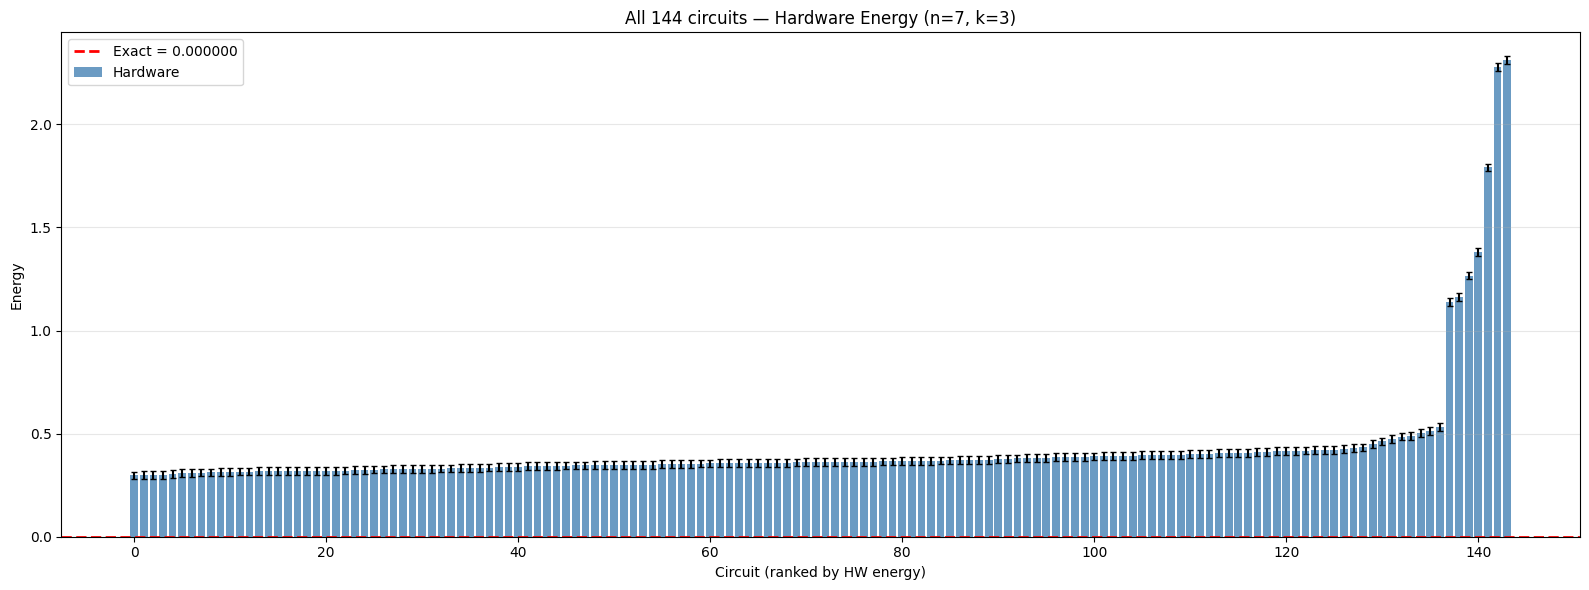

Saved plot -> n7k3_all_results/all_hw_energies.png


In [8]:
import matplotlib.pyplot as plt

hw_energies = [e["hw_energy"] for e in ranked]
hw_stds = [e["hw_std"] if e["hw_std"] is not None else 0 for e in ranked]

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(ranked))
ax.bar(x, hw_energies, yerr=hw_stds, capsize=2, color="steelblue", alpha=0.8, label="Hardware")
ax.axhline(y=exact_energy, color="red", linestyle="--", linewidth=2, label=f"Exact = {exact_energy:.6f}")
ax.set_xlabel("Circuit (ranked by HW energy)")
ax.set_ylabel("Energy")
ax.set_title(f"All {len(ranked)} circuits — Hardware Energy (n={NUM_QUBITS}, k={NUMK})")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(ALL_RESULTS_DIR, "all_hw_energies.png"), dpi=150)
plt.show()
print(f"Saved plot -> {ALL_RESULTS_DIR}/all_hw_energies.png")

## Step 8: Save all results

In [9]:
# ---- Save ALL results to n7k3_all_results/ ----
hw_csv = os.path.join(ALL_RESULTS_DIR, "hardware_all_results.csv")
with open(hw_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["rank", "circuit_file", "hw_energy", "hw_std", "hw_error_vs_exact",
                      "sim_energy", "original_rzz", "transpiled_2q", "transpiled_depth",
                      "chain", "chain_error_score", "shots", "resilience_level", "job_id", "elapsed_s"])
    for rank, e in enumerate(ranked):
        writer.writerow([rank + 1, e["fname"], e["hw_energy"], e["hw_std"], e["hw_error"],
                         e["sim_energy"], e["original_rzz"], e["transpiled_2q"],
                         e["transpiled_depth"], e["chain"], e["chain_error_score"],
                         e["shots"], e["resilience_level"], e["job_id"], e["elapsed_s"]])
print(f"Saved all hardware results -> {hw_csv}")

all_log = {
    "timestamp": datetime.now().isoformat(),
    "backend": backend.name,
    "num_qubits": NUM_QUBITS,
    "numk": NUMK,
    "exact_ground_energy": float(exact_energy),
    "chain": best_chain,
    "chain_error_score": best_score,
    "shots": SHOTS,
    "resilience_level": RESILIENCE,
    "num_circuits": len(transpiled_all),
    "circuits": [
        {
            "rank": rank + 1,
            "circuit_file": e["fname"],
            "sim_energy": e["sim_energy"],
            "hw_energy": e["hw_energy"],
            "hw_std": e["hw_std"],
            "hw_error_vs_exact": e["hw_error"],
            "original_rzz": e["original_rzz"],
            "original_depth": e["original_depth"],
            "transpiled_2q": e["transpiled_2q"],
            "transpiled_depth": e["transpiled_depth"],
            "transpiled_ops": e["transpiled_ops"],
            "job_id": e["job_id"],
            "elapsed_s": e["elapsed_s"],
        }
        for rank, e in enumerate(ranked)
    ],
}
all_log_path = os.path.join(ALL_RESULTS_DIR, "hardware_all_log.json")
with open(all_log_path, "w") as f:
    json.dump(all_log, f, indent=2)
print(f"Saved full JSON log -> {all_log_path}")

Saved all hardware results -> n7k3_all_results/hardware_all_results.csv
Saved full JSON log -> n7k3_all_results/hardware_all_log.json


In [10]:
# ---- Save BEST circuit to main folder (same format as n=8, k=2) ----
best = ranked[1]
tag = f"n_{NUM_QUBITS}_k_{NUMK}"
best_ops = best["transpiled_circ"].count_ops()

try:
    phys_qubits = best["transpiled_circ"].layout.final_index_layout(filter_ancillas=True)
except Exception:
    phys_qubits = list(range(NUM_QUBITS))

best_log = {
    "timestamp": datetime.now().isoformat(),
    "backend": backend.name,
    "num_qubits": NUM_QUBITS,
    "numk": NUMK,
    "best_circuit_file": best["fname"],
    "simulator_energy": float(best["sim_energy"]),
    "exact_ground_energy": float(exact_energy),
    "original_circuit": {
        "depth": best["original_depth"],
        "rzz_gates": best["original_rzz"],
    },
    "transpiled_circuit": {
        "depth": best["transpiled_depth"],
        "gate_counts": {str(k): int(v) for k, v in best_ops.items()},
        "two_qubit_gates": best["transpiled_2q"],
        "physical_qubits": phys_qubits,
        "chain": best["chain"],
        "chain_error_score": best["chain_error_score"],
    },
    "evaluations": {
        "raw": {
            "energy": best["hw_energy"],
            "std": best["hw_std"],
            "error_vs_exact": best["hw_error"],
            "resilience_level": best["resilience_level"],
            "shots": best["shots"],
            "job_id": best["job_id"],
            "elapsed_seconds": best["elapsed_s"],
        }
    },
}

try:
    cal_props = backend.properties()
    if cal_props:
        calib = {"timestamp": str(cal_props.last_update_date), "qubit_properties": {}}
        for q in phys_qubits:
            calib["qubit_properties"][str(q)] = {
                "T1": cal_props.t1(q),
                "T2": cal_props.t2(q),
                "readout_error": cal_props.readout_error(q),
            }
        best_log["backend_calibration"] = calib
except Exception as e:
    print(f"Could not capture calibration: {e}")

best_log_path = f"hardware_eval_log_{tag}.json"
with open(best_log_path, "w") as f:
    json.dump(best_log, f, indent=2)
print(f"Saved best log -> {best_log_path}")

best_qpy_path = f"hardware_transpiled_circuit_{tag}.qpy"
with open(best_qpy_path, "wb") as f:
    qpy.dump(best["transpiled_circ"], f)
print(f"Saved best transpiled circuit -> {best_qpy_path}")

best_csv_path = f"hardware_eval_summary_{tag}.csv"
with open(best_csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["config", "energy", "std", "error_vs_exact", "resilience_level", "shots", "job_id", "elapsed_s"])
    writer.writerow(["raw", best["hw_energy"], best["hw_std"], best["hw_error"],
                     best["resilience_level"], best["shots"], best["job_id"], best["elapsed_s"]])
print(f"Saved best summary -> {best_csv_path}")

print(f"\n{'='*60}")
print(f"All results saved to:")
print(f"  {ALL_RESULTS_DIR}/  ({len(transpiled_all)} circuits)")
print(f"    - transpile_summary.csv")
print(f"    - hardware_all_results.csv")
print(f"    - hardware_all_log.json")
print(f"    - transpiled_circuits/ ({len(transpiled_all)} .qpy files)")
print(f"    - all_hw_energies.png")
print(f"Best circuit (lowest HW energy) also saved to current folder:")
print(f"  {best_log_path}")
print(f"  {best_qpy_path}")
print(f"  {best_csv_path}")
print(f"{'='*60}")

Saved best log -> hardware_eval_log_n_7_k_3.json
Saved best transpiled circuit -> hardware_transpiled_circuit_n_7_k_3.qpy
Saved best summary -> hardware_eval_summary_n_7_k_3.csv

All results saved to:
  n7k3_all_results/  (144 circuits)
    - transpile_summary.csv
    - hardware_all_results.csv
    - hardware_all_log.json
    - transpiled_circuits/ (144 .qpy files)
    - all_hw_energies.png
Best circuit (lowest HW energy) also saved to current folder:
  hardware_eval_log_n_7_k_3.json
  hardware_transpiled_circuit_n_7_k_3.qpy
  hardware_eval_summary_n_7_k_3.csv
